In [166]:
from pylab import *
SDS_20=loadtxt('SDS_20mM_compiled.txt')
SDS_10=loadtxt('SDS_10mM_day2_better.txt')
SDS_15=loadtxt('SDS_15mM.txt')
SDS_8=loadtxt('SDS_8mM.txt')
SDS_6=loadtxt('SDS_6mM.txt')
SDS_4=loadtxt('SDS_4mM.txt')
SDS_3=loadtxt('SDS_3mM.txt')
SDS_2=loadtxt('SDS_2mM_day2.txt')
SDS_1=loadtxt('SDS_1mM.txt')

In [198]:
SDS_20_g=SDS_20[:,7]
SDS_10_g=SDS_10[:,7]
SDS_2_g=SDS_2[:,7]
SDS_15_g=SDS_15[:,7]
SDS_8_g=SDS_8[:,7]
SDS_6_g=SDS_6[:,7]
SDS_4_g=SDS_4[:,7]
SDS_3_g=SDS_3[:,7]
SDS_1_g=SDS_1[:,7]

mean_g=[mean(SDS_20_g),mean(SDS_15_g),mean(SDS_10_g),mean(SDS_8_g),mean(SDS_6_g),mean(SDS_4_g),mean(SDS_3_g),mean(SDS_2_g),mean(SDS_1_g)]
std_g=array([std(SDS_20_g),std(SDS_15_g),std(SDS_10_g),std(SDS_8_g),std(SDS_6_g),std(SDS_4_g),std(SDS_3_g),std(SDS_2_g),std(SDS_1_g)])/(5**0.5)

In [190]:
std_g=[std(SDS_20_g),std(SDS_15_g),std(SDS_10_g),std(SDS_8_g),std(SDS_6_g),std(SDS_4_g),std(SDS_3_g),std(SDS_2_g),std(SDS_1_g)]

In [199]:
mean_g

[np.float64(34.952729337670156),
 np.float64(33.59365702027047),
 np.float64(34.08773361048336),
 np.float64(34.78335146966852),
 np.float64(34.154620740649825),
 np.float64(38.7391825045291),
 np.float64(43.13397936962722),
 np.float64(47.14108996695721),
 np.float64(54.310349982079515)]

In [200]:
std_g

array([1.25416212, 0.8918006 , 0.29113183, 1.20949637, 1.03075356,
       0.67217602, 0.44588241, 0.75201554, 0.41543505])

In [201]:
conc=array([20,15,10,8,6,4,3,2,1])

In [202]:
conc[-4:]

array([4, 3, 2, 1])

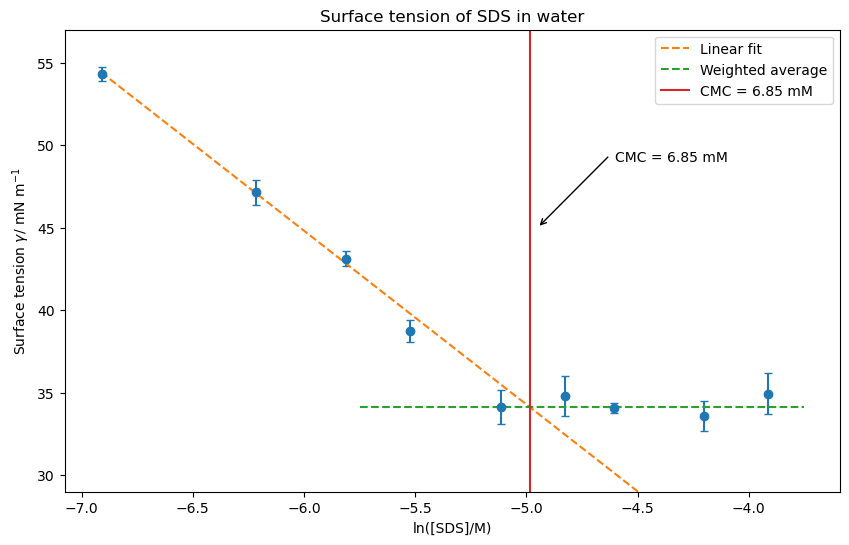

In [203]:
figure(figsize=(10,6))
ylim(29,57)

water_fit=polyfit(log(conc[-5:]/1000),mean_g[-5:],1,cov=True,w=1/array(std_g[-5:])**2)
params=water_fit[0]
m,c=params

water_fitted=m*log((conc/1000))+c

errorbar(log((conc/1000)),mean_g, linestyle='',marker='o',yerr=std_g,xerr=err_list,capsize=3)
plot(log((conc/1000)),water_fitted,linestyle='--',label='Linear fit')

water_plateau=average(mean_g[:5],weights=1/((array(std_g[:5]))**2))
plot([-5.75,-3.75],[water_plateau,water_plateau],linestyle='--',label='Weighted average')

cmc_water=(water_plateau-c)/m


title('Surface tension of SDS in water')
xlabel('ln([SDS]/M)')
ylabel(r'Surface tension $\gamma$/ mN m$^{-1}$')

annotation='CMC = '+str(round(exp(cmc_water)*1000,2))+' mM'
annotate('',xy=(-4.95,45),xytext=(-4.625,49.4),arrowprops=dict(arrowstyle="->"))
text(-4.6,49,annotation)
plot([cmc_water,cmc_water],[25,57],linestyle='-',label=annotation)

legend()

savefig('Water.jpeg',bbox_inches='tight',dpi=300)


show()

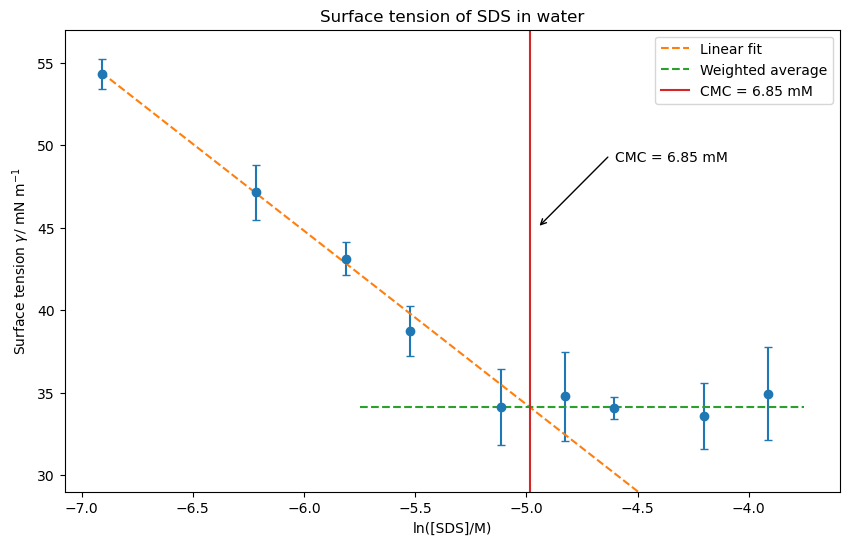

In [196]:
figure(figsize=(10,6))
ylim(29,57)

water_fit=polyfit(log(conc[-5:]/1000),mean_g[-5:],1,cov=True,w=1/array(std_g[-5:])**2)
params=water_fit[0]
m,c=params

water_fitted=m*log((conc/1000))+c

errorbar(log((conc/1000)),mean_g, linestyle='',marker='o',yerr=std_g,xerr=err_list,capsize=3)
plot(log((conc/1000)),water_fitted,linestyle='--',label='Linear fit')

water_plateau=average(mean_g[:5],weights=1/((array(std_g[:5]))**2))
plot([-5.75,-3.75],[water_plateau,water_plateau],linestyle='--',label='Weighted average')

cmc_water=(water_plateau-c)/m


title('Surface tension of SDS in water')
xlabel('ln([SDS]/M)')
ylabel(r'Surface tension $\gamma$/ mN m$^{-1}$')

annotation='CMC = '+str(round(exp(cmc_water)*1000,2))+' mM'
annotate('',xy=(-4.95,45),xytext=(-4.625,49.4),arrowprops=dict(arrowstyle="->"))
text(-4.6,49,annotation)
plot([cmc_water,cmc_water],[25,57],linestyle='-',label=annotation)

legend()

savefig('Water.jpeg',bbox_inches='tight',dpi=300)


show()

In [183]:
cmc_water_min

np.float64(-5.013798853163322)

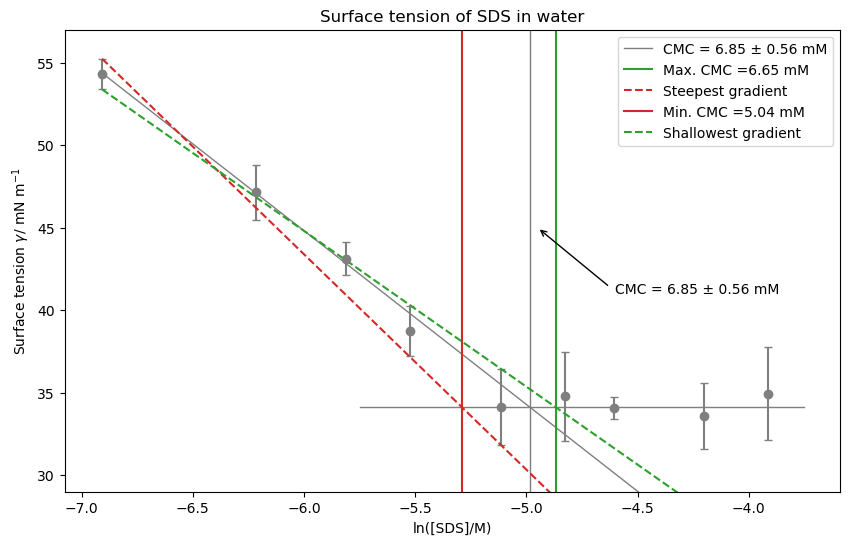

In [184]:
conc=array([20,15,10,8,6,4,3,2,1])
figure(figsize=(10,6))
ylim(29,57)

title('Surface tension of SDS in water')
xlabel('ln([SDS]/M)')
ylabel(r'Surface tension $\gamma$/ mN m$^{-1}$')

#plotting data
annotation='CMC = '+str(round(exp(cmc_water)*1000,2))+' ± '+str(round(cmc_uncertainty,2))+' mM'
errorbar(log((conc/1000)),mean_g, linestyle='',marker='o',yerr=std_g,xerr=err_list,capsize=3,color='tab:grey')

#weighted linear fit
water_fit=polyfit(log(conc[-5:]/1000),mean_g[-5:],1,cov=True,w=1/((array(std_g[-5:])*(5**0.5))**2))
params=water_fit[0]
m,c=params
water_fitted=m*log((conc/1000))+c
plot(log((conc/1000)),water_fitted,linestyle='-',color='tab:grey',linewidth=1)


#weighted average for the plateau
water_plateau=average(mean_g[:5],weights=1/((array(std_g[:5]))**2))
plot([-5.75,-3.75],[water_plateau,water_plateau],linestyle='-',color='tab:grey',linewidth=1)

#calculating intercept
cmc_water=(water_plateau-c)/m
cmc_water1 = exp(cmc_water)*1000
plot([cmc_water,cmc_water],[25,57],linestyle='-',color='tab:grey',label=annotation,linewidth=1)

#calculating best and worst gradients
m_max=((mean_g[-1]+std_g[-1]-(mean_g[-5]-std_g[-5])))/(log(conc[-1]/1000)-log(conc[-5]/1000))
c_max=(mean_g[-1]+std_g[-1])-(m_max*log(conc[-1]/1000))

m_min=((mean_g[-1]-std_g[-1])-(mean_g[-5]+std_g[-5]))/(log(conc[-1]/1000)-log(conc[-5]/1000))
c_min=(mean_g[-1]-std_g[-1])-(m_min*log(conc[-1]/1000))

#Calculating and plotting min and max cmc
cmc_water_min=(water_plateau-c_min)/m_min
cmc_water_max=(water_plateau-c_max)/m_max
plot([cmc_water_min,cmc_water_min],[25,57],linestyle='-',color='tab:green',label=annotation_min)

#plotting worst and best gradients
annotation_min='Max. CMC ='+str(round(exp(cmc_water_min)*1000,2))+' mM'
annotation_max='Min. CMC ='+str(round(exp(cmc_water_max)*1000,2))+' mM'
plot(linspace(log(conc[-1]/1000),-4,10),linspace(log(conc[-1]/1000),-4,10)*m_max+c_max,color='tab:red',linestyle='--',label='Steepest gradient')
plot([cmc_water_max,cmc_water_max],[25,57],linestyle='-',color='tab:red',label=annotation_max)

plot(linspace(log(conc[-1]/1000),-4,10),linspace(log(conc[-1]/1000),-4,10)*m_min+c_min,color='tab:green',linestyle='--',label='Shallowest gradient')



cmc_uncertainty=(-exp(cmc_water_max)*1000+exp(cmc_water_min)*1000)/2
annotate('',xy=(-4.95,45),xytext=(-4.625,41.4),arrowprops=dict(arrowstyle="->"))
text(-4.6,41,annotation)

legend()

savefig('Water_analysed.jpeg',bbox_inches='tight',dpi=300)
show()


In [185]:
exp((water_plateau-c)/m*1000)

np.float64(0.0)

In [186]:
m_max=((mean_g[-1]+std_g[-1]-(mean_g[-5]-std_g[-5])))/(log(conc[-1]/1000)-log(conc[-5]/1000))
c_max=(mean_g[-1]+std_g[-1])-(m_max*log(conc[-1]/1000))
m_max,c_max

(np.float64(-13.053931444074877), np.float64(-34.934072852761425))

In [187]:
m_min=((mean_g[-1]-std_g[-1])-(mean_g[-5]+std_g[-5]))/(log(conc[-1]/1000)-log(conc[-5]/1000))
c_min=(mean_g[-1]-std_g[-1])-(m_min*log(conc[-1]/1000))
m_min,c_min

(np.float64(-9.44432190698837), np.float64(-11.857655536764234))

In [188]:
linspace(-7,-4,10)*m_max+c_max

array([56.44344726, 52.09213677, 47.74082629, 43.38951581, 39.03820533,
       34.68689485, 30.33558437, 25.98427389, 21.6329634 , 17.28165292])

In [189]:
log(conc[-5]/1000)

np.float64(-5.115995809754082)

In [149]:
nacl_20=loadtxt("SDS(NaCl)_20mM.txt")
nacl_10=loadtxt("SDS(NaCl)_10mM_day2.txt")
nacl_15=loadtxt("SDS(NaCl)_15mM_day2.txt")
nacl_8=loadtxt("SDS(NaCl)_8mM.txt")
nacl_6=loadtxt("SDS(NaCl)_6mM.txt")
nacl_4=loadtxt("SDS(NaCl)_4mM.txt")
nacl_3=loadtxt("SDS(NaCl)_3mM_day2.txt")
nacl_2=loadtxt("SDS(NaCl)_2mM.txt")
nacl_1=loadtxt("SDS(NaCl)_1mM.txt")

In [150]:
nacl_20_g=nacl_20[:,7]
nacl_15_g=nacl_15[:,7]
nacl_10_g=nacl_10[:,7]
nacl_8_g=nacl_8[:,7]
nacl_6_g=nacl_6[:,7]
nacl_4_g=nacl_4[:,7]
nacl_3_g=nacl_3[:,7]
nacl_2_g=nacl_2[:,7]
nacl_1_g=nacl_1[:,7]

mean_nacl_g=[mean(nacl_20_g),mean(nacl_15_g),mean(nacl_10_g),mean(nacl_8_g),mean(nacl_6_g),mean(nacl_4_g),mean(nacl_3_g),mean(nacl_2_g),mean(nacl_1_g)]
std_nacl_g=array([std(nacl_20_g),std(nacl_15_g),std(nacl_10_g),std(nacl_8_g),std(nacl_6_g),std(nacl_4_g),std(nacl_3_g),std(nacl_2_g),std(nacl_1_g)])/(5**0.5)

In [151]:
std_nacl_g

array([0.11795051, 0.2998742 , 0.70612506, 0.4183457 , 0.17232486,
       0.42386527, 0.5219804 , 0.63322941, 0.75763744])

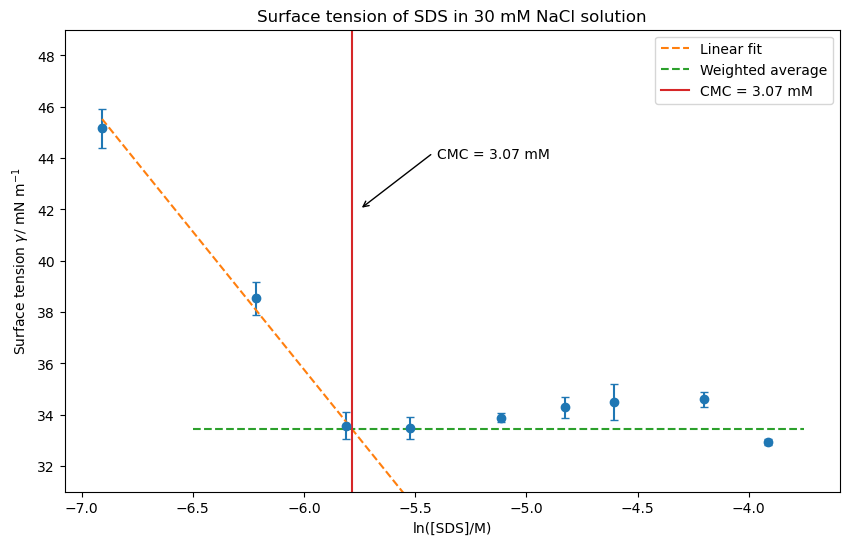

In [152]:
figure(figsize=(10,6))
ylim(31,49)

nacl_fit=polyfit(log(conc[-3:]/1000),mean_nacl_g[-3:],1,cov=True,w=1/array(std_nacl_g[-3:])**2)
params=nacl_fit[0]
m,c=params

nacl_fitted=m*log((conc/1000))+c

errorbar(log((conc/1000)),mean_nacl_g, linestyle='',marker='o',yerr=std_nacl_g,xerr=err_list,capsize=3)
plot(log((conc/1000)),nacl_fitted,linestyle='--',label='Linear fit')

nacl_plateau=average(mean_nacl_g[:7],weights=1/(array(std_nacl_g[:7]))**2)
plot([-6.5,-3.75],[nacl_plateau,nacl_plateau],linestyle='--',label='Weighted average')


cmc_nacl=(nacl_plateau-c)/m

annotation='CMC = '+str(round(exp(cmc_nacl)*1000,2))+' mM'
annotate('',xy=(-5.75,42),xytext=(-5.42,44.2),arrowprops=dict(arrowstyle="->"))
text(-5.4,44,annotation)
plot([cmc_nacl,cmc_nacl],[31,49],linestyle='-',label=annotation)

title('Surface tension of SDS in 30 mM NaCl solution')
xlabel('ln([SDS]/M)')
ylabel(r'Surface tension $\gamma$/ mN m$^{-1}$')



legend()

savefig('NaCl.jpeg',bbox_inches='tight',dpi=300)

show()

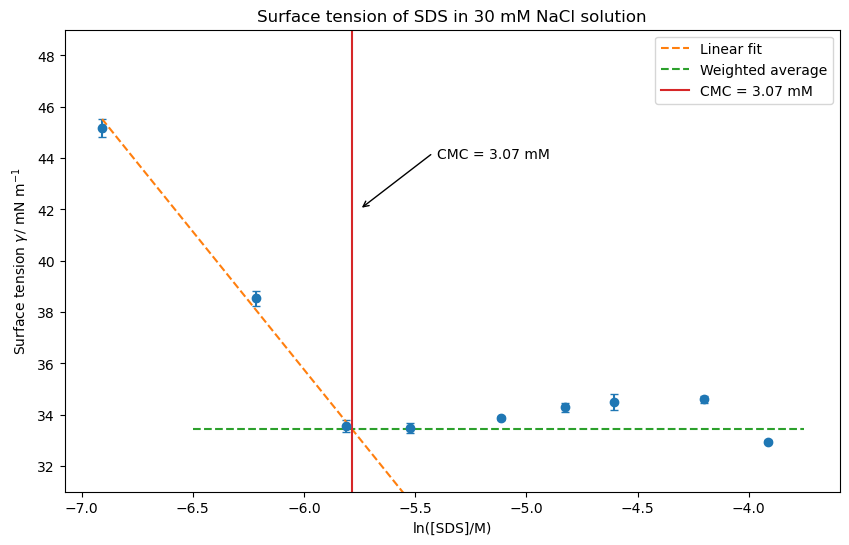

In [153]:
figure(figsize=(10,6))
ylim(31,49)

nacl_fit=polyfit(log(conc[-3:]/1000),mean_nacl_g[-3:],1,cov=True,w=1/array(std_nacl_g[-3:])**2)
params=nacl_fit[0]
m,c=params

nacl_fitted=m*log((conc/1000))+c

errorbar(log((conc/1000)),mean_nacl_g, linestyle='',marker='o',yerr=array(std_nacl_g)/(5**0.5),xerr=err_list,capsize=3)
plot(log((conc/1000)),nacl_fitted,linestyle='--',label='Linear fit')

nacl_plateau=average(mean_nacl_g[:7],weights=1/(array(std_nacl_g[:7]))**2)
plot([-6.5,-3.75],[nacl_plateau,nacl_plateau],linestyle='--',label='Weighted average')


cmc_nacl=(nacl_plateau-c)/m

annotation='CMC = '+str(round(exp(cmc_nacl)*1000,2))+' mM'
annotate('',xy=(-5.75,42),xytext=(-5.42,44.2),arrowprops=dict(arrowstyle="->"))
text(-5.4,44,annotation)
plot([cmc_nacl,cmc_nacl],[31,49],linestyle='-',label=annotation)

title('Surface tension of SDS in 30 mM NaCl solution')
xlabel('ln([SDS]/M)')
ylabel(r'Surface tension $\gamma$/ mN m$^{-1}$')



legend()

savefig('NaCl.jpeg',bbox_inches='tight',dpi=300)

show()

In [154]:
cmc_uncertainty=(-cmc_nacl_max+cmc_nacl_min)/2
cmc_uncertainty

np.float64(0.051429018529172144)

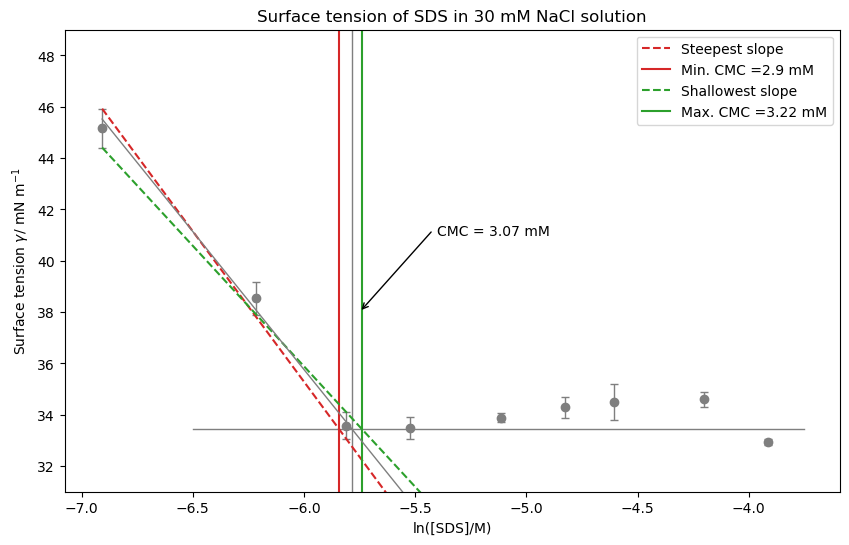

In [155]:
figure(figsize=(10,6))
ylim(31,49)
title('Surface tension of SDS in 30 mM NaCl solution')
xlabel('ln([SDS]/M)')
ylabel(r'Surface tension $\gamma$/ mN m$^{-1}$')

#Linear fit
nacl_fit=polyfit(log(conc[-3:]/1000),mean_nacl_g[-3:],1,cov=True,w=1/array(std_nacl_g[-3:])**2)
params=nacl_fit[0]
m,c=params

nacl_fitted=m*log((conc/1000))+c

#plotting data and linear fit
errorbar(log((conc/1000)),mean_nacl_g, linestyle='',marker='o',yerr=std_nacl_g,xerr=err_list,capsize=3,color='tab:grey',linewidth=1)

#calculating and plotting weighted average
nacl_plateau=average(mean_nacl_g[:7],weights=1/(array(std_nacl_g[:7]))**2)
plot([-6.5,-3.75],[nacl_plateau,nacl_plateau],linestyle='-',color='tab:grey',linewidth=1)

#calculating and plotting cmc
cmc_nacl=(nacl_plateau-c)/m
plot([cmc_nacl,cmc_nacl],[31,49],linestyle='-',color='tab:grey',linewidth=1)

#calculating best and worst gradients
m_max=((mean_nacl_g[-1]+std_nacl_g[-1]-(mean_nacl_g[-3]-std_nacl_g[-3])))/(log(conc[-1]/1000)-log(conc[-3]/1000))
c_max=(mean_nacl_g[-1]+std_nacl_g[-1])-(m_max*log(conc[-1]/1000))

m_min=((mean_nacl_g[-1]-std_nacl_g[-1])-(mean_nacl_g[-3]+std_nacl_g[-3]))/(log(conc[-1]/1000)-log(conc[-3]/1000))
c_min=(mean_nacl_g[-1]-std_nacl_g[-1])-(m_min*log(conc[-1]/1000))

cmc_nacl_min=(nacl_plateau-c_min)/m_min
cmc_nacl_max=(nacl_plateau-c_max)/m_max
annotation_min='Max. CMC ='+str(round(exp(cmc_nacl_min)*1000,2))+' mM'
annotation_max='Min. CMC ='+str(round(exp(cmc_nacl_max)*1000,2))+' mM'

plot(linspace(log(conc[-1]/1000),-4,10),linspace(log(conc[-1]/1000),-4,10)*m_max+c_max,color='tab:red',linestyle='--',label='Steepest slope')
plot([cmc_nacl_max,cmc_nacl_max],[25,57],linestyle='-',color='tab:red',label=annotation_max)
plot(linspace(log(conc[-1]/1000),-4,10),linspace(log(conc[-1]/1000),-4,10)*m_min+c_min,color='tab:green',linestyle='--',label='Shallowest slope')
plot([cmc_nacl_min,cmc_nacl_min],[25,57],linestyle='-',color='tab:green',label=annotation_min)

cmc_uncertainty=(-exp(cmc_nacl_max)*1000+exp(cmc_nacl_min)*1000)/2

annotate('',xy=(-5.75,38),xytext=(-5.42,41.2),arrowprops=dict(arrowstyle="->"))
text(-5.4,41,annotation)

legend()

savefig('NaCl_analysed.jpeg',bbox_inches='tight',dpi=300)

annotation='CMC = '+str(round(exp(cmc_nacl)*1000,2))+' ± '+str(round(cmc_uncertainty,2))+' mM'
plot(log((conc/1000)),nacl_fitted,linestyle='-',color='tab:grey',linewidth=1,label=annotation)

show()

In [156]:
cmc_nacl1 = exp(cmc_nacl)*1000
cmc_water1 = exp(cmc_water)*1000

In [157]:
from pylab import *

In [158]:
pip_err=[(7*(0.008**2)+0.005**2)**0.5,(5**0.5)*0.008,(4**0.5)*0.008,(3**0.5)*0.008,(2**0.5)*0.008,(0.005**2+0.008**2)**0.5,0.008,0.005]
vol=[7.5,5,4,3,2,1.5,1,0.5]
conc_err=[15,10,8,6,4,3,2,1]

In [159]:
err_list=[]
for i in range(len(pip_err)):
    err_list+=[(((pip_err[i]/vol[i])**2+(0.02/10)**2)**0.5)]

In [160]:
err_list

[0.0035226252836327754,
 0.00409878030638384,
 0.004472135954999579,
 0.005033222956847166,
 0.006000000000000001,
 0.006599663291074443,
 0.00824621125123532,
 0.01019803902718557]

In [161]:
err_list.insert(0,0)

In [162]:
err_list

[0,
 0.0035226252836327754,
 0.00409878030638384,
 0.004472135954999579,
 0.005033222956847166,
 0.006000000000000001,
 0.006599663291074443,
 0.00824621125123532,
 0.01019803902718557]